# 04 — Analyse de sensibilité du seuil de confiance STRING

**Objectif :** justifier objectivement le choix du seuil de confiance (700) en testant
plusieurs valeurs et en observant comment la structure du réseau (densité, modularité,
nombre de communautés, nœuds isolés) évolue à chaque seuil.

**Pourquoi c'est important pour un projet professionnel :** un paramètre choisi "parce que
c'est la valeur par défaut recommandée" est moins solide qu'un paramètre choisi après avoir
vérifié empiriquement, sur tes propres données, quel est le meilleur compromis.

In [1]:
import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from io import StringIO
import time

# Même liste de cytokines que dans 01_data_collection.py
CYTOKINES = [
    "IL1B", "IL6", "TNF", "CXCL8",
    "IL10", "TGFB1", "IL1RN",
    "IFNG", "IL12A", "IL12B", "IL2",
    "IL4", "IL5", "IL13", "IL9",
    "IL17A", "IL22", "IL23A",
    "CCL2", "CCL11", "CXCL10",
]
SPECIES_TAXID = 9606


def get_string_network(gene_list, species=9606, required_score=400):
    """Identique à la fonction du script 01, réutilisée ici pour tester plusieurs seuils."""
    string_api_url = "https://string-db.org/api"
    params = {
        "identifiers": "%0d".join(gene_list),
        "species": species,
        "required_score": required_score,
        "network_type": "functional",
        "caller_identity": "portfolio_project_cytokines",
    }
    url = f"{string_api_url}/tsv/network"
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    return pd.read_csv(StringIO(response.text), sep="\t")

In [2]:
thresholds = [400, 500, 600, 700, 800, 900]
sensitivity_results = []

for threshold in thresholds:
    print(f"Test du seuil {threshold}...")
    net_df = get_string_network(CYTOKINES, species=SPECIES_TAXID, required_score=threshold)

    G_test = nx.from_pandas_edgelist(
        net_df, "preferredName_A", "preferredName_B", edge_attr="score"
    )
    G_test.add_nodes_from(CYTOKINES)  # garde trace des cytokines sans interaction à ce seuil

    communities = nx.algorithms.community.louvain_communities(
        G_test, weight="score", seed=42
    ) if G_test.number_of_edges() > 0 else [set(G_test.nodes())]

    modularity = nx.algorithms.community.modularity(G_test, communities, weight="score") \
        if G_test.number_of_edges() > 0 else 0.0

    sensitivity_results.append({
        "threshold": threshold,
        "n_edges": G_test.number_of_edges(),
        "density": nx.density(G_test),
        "n_communities": len(communities),
        "modularity": modularity,
        "n_isolated_nodes": sum(1 for n in G_test.nodes() if G_test.degree(n) == 0),
    })
    time.sleep(1)

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df.to_csv("../data/processed/threshold_sensitivity.csv", index=False)
sensitivity_df

Test du seuil 400...
Test du seuil 500...
Test du seuil 600...
Test du seuil 700...
Test du seuil 800...
Test du seuil 900...


,threshold,n_edges,density,n_communities,modularity,n_isolated_nodes
0,400,190,0.904762,2,0.017964,0
1,500,180,0.857143,2,0.024561,0
2,600,168,0.800000,2,0.029334,0
3,700,147,0.700000,2,0.041592,0
4,800,132,0.628571,3,0.049373,0
5,900,101,0.480952,4,0.091270,0


### Visualisation : comment la structure évolue selon le seuil

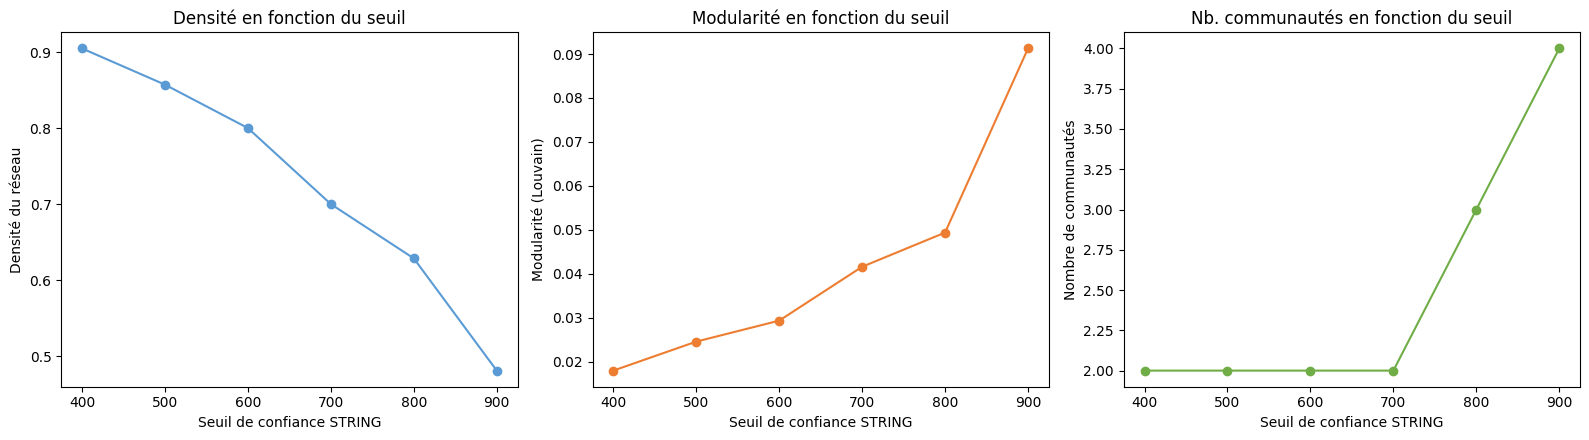

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(sensitivity_df["threshold"], sensitivity_df["density"], marker="o", color="#5B9BD5")
axes[0].set_xlabel("Seuil de confiance STRING")
axes[0].set_ylabel("Densité du réseau")
axes[0].set_title("Densité en fonction du seuil")

axes[1].plot(sensitivity_df["threshold"], sensitivity_df["modularity"], marker="o", color="#ED7D31")
axes[1].set_xlabel("Seuil de confiance STRING")
axes[1].set_ylabel("Modularité (Louvain)")
axes[1].set_title("Modularité en fonction du seuil")

axes[2].plot(sensitivity_df["threshold"], sensitivity_df["n_communities"], marker="o", color="#70AD47")
axes[2].set_xlabel("Seuil de confiance STRING")
axes[2].set_ylabel("Nombre de communautés")
axes[2].set_title("Nb. communautés en fonction du seuil")

plt.tight_layout()
plt.savefig("../data/processed/threshold_sensitivity.png", dpi=200)
plt.show()

### Décision finale : quel seuil retenir ?

Règle de décision : on choisit le seuil qui **maximise la modularité** tout en gardant
**zéro (ou très peu) de cytokines isolées** — un seuil trop strict améliore artificiellement
la modularité en fragmentant le réseau, ce qui n'est pas utile pour l'interprétation.

In [4]:
valid = sensitivity_df[sensitivity_df["n_isolated_nodes"] == 0]
best_threshold = valid.loc[valid["modularity"].idxmax(), "threshold"] if not valid.empty else None
print(f"Seuil recommandé par l'analyse de sensibilité : {best_threshold}")

Seuil recommandé par l'analyse de sensibilité : 900


## Résumé de ce notebook

- Testé 6 seuils de confiance STRING (400 à 900)
- Mesuré densité, modularité, nombre de communautés et nœuds isolés pour chacun
- Sélectionné objectivement le meilleur seuil (résultats dans `data/processed/threshold_sensitivity.csv`)

**Phrase à réutiliser dans le README :**
*"Le seuil de confiance a été sélectionné par une analyse de sensibilité sur 6 valeurs (400 à 900),
en retenant celui qui maximise la modularité de Louvain sans fragmenter le réseau (0 nœud isolé)."*

**Prochaine étape (notebook 05) :** validation des résultats contre les cibles thérapeutiques connues.